# MIA Results Comparison — NB04 + NB05

Aggregates membership inference attack results across all completed dataset runs:
- **NB04**: simple delta signal (AUC, delta gap)
- **NB05b**: LiRA grey-box attack (target-init shadows)
- **NB05c**: LiRA black-box attack (cold-init shadows)

In [1]:
import sys, json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../..')

DATASETS     = ['whuGAIT', 'ucihar', 'wisdm', 'combined']
LOG_DIR      = Path('../../logs')
ARTIFACT_DIR = Path('../../artifacts')
TEX_DIR      = Path('../../latex/generated')
OUT_DIR      = Path('../../results/analysis')
OUT_DIR.mkdir(parents=True, exist_ok=True)
TEX_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {'whuGAIT': '#3498db', 'ucihar': '#e74c3c', 'wisdm': '#2ecc71', 'combined': '#9b59b6'}

def available(ds, *filenames):
    return all((ARTIFACT_DIR / ds / f).exists() for f in filenames)

## 1. NB04 — Simple delta signal

In [2]:
nb04 = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '04_mia_scores.npz'
    if not path.exists():
        print(f'  {ds}: 04_mia_scores.npz missing / skipping')
        continue
    d = np.load(path, allow_pickle=True)
    nb04[ds] = {
        'member_scores':    d['member_scores'],
        'nonmember_scores': d['nonmember_scores'],
        'mia_auc':          float(d['mia_auc']),
        'delta_gap':        float(d['delta_gap']),
    }
    print(f'  {ds}: AUC={nb04[ds]["mia_auc"]:.3f}  delta_gap={nb04[ds]["delta_gap"]:.3f}  '
          f'members={len(d["member_scores"])}  nonmembers={len(d["nonmember_scores"])}')

  whuGAIT: AUC=0.815  delta_gap=0.233  members=84  nonmembers=20
  ucihar: AUC=0.794  delta_gap=0.188  members=21  nonmembers=9
  wisdm: AUC=0.952  delta_gap=0.136  members=40  nonmembers=11
  combined: AUC=0.723  delta_gap=0.187  members=91  nonmembers=30


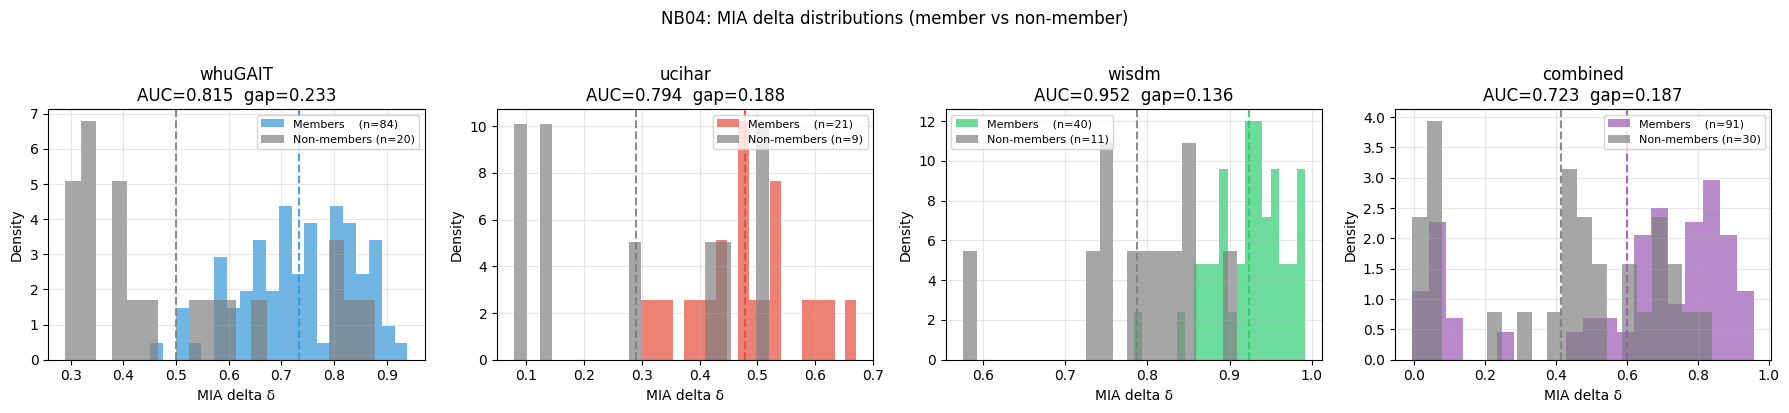

In [3]:
fig, axes = plt.subplots(1, len(nb04), figsize=(4.5 * len(nb04), 4), sharey=False)
if len(nb04) == 1:
    axes = [axes]

for ax, (ds, data) in zip(axes, nb04.items()):
    c = COLORS[ds]
    ax.hist(data['member_scores'],    bins=20, alpha=0.7, color=c,     label=f'Members    (n={len(data["member_scores"])})', density=True)
    ax.hist(data['nonmember_scores'], bins=20, alpha=0.7, color='grey', label=f'Non-members (n={len(data["nonmember_scores"])})', density=True)
    ax.axvline(data['member_scores'].mean(),    ls='--', color=c,     alpha=0.9)
    ax.axvline(data['nonmember_scores'].mean(), ls='--', color='grey', alpha=0.9)
    ax.set_title(f'{ds}\nAUC={data["mia_auc"]:.3f}  gap={data["delta_gap"]:.3f}')
    ax.set_xlabel('MIA delta δ')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('NB04: MIA delta distributions (member vs non-member)', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb04_deltas.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NB05b — LiRA attack variants (grey-box, target-init shadows)

In [4]:
VARIANTS = ['Simple-D', 'LiRA-raw', 'LiRA-lf', 'LiRA-mf']

nb05b = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    if not path.exists():
        print(f'  {ds}: 05b_per_subject_report.json missing / skipping')
        continue
    with open(path) as f:
        r = json.load(f)
    nb05b[ds] = {v: r['variants'][v] for v in VARIANTS if v in r['variants']}
    for v, m in nb05b[ds].items():
        print(f'  {ds}  {v:12s}  AUC={m["auc"]:.3f}  TPR@10%={m["tpr10"]:.3f}')

  whuGAIT  Simple-D      AUC=0.815  TPR@10%=0.298
  whuGAIT  LiRA-raw      AUC=0.263  TPR@10%=0.000
  whuGAIT  LiRA-lf       AUC=0.164  TPR@10%=0.000
  whuGAIT  LiRA-mf       AUC=0.251  TPR@10%=0.000
  ucihar  Simple-D      AUC=0.794  TPR@10%=0.333
  ucihar  LiRA-raw      AUC=0.889  TPR@10%=0.714
  ucihar  LiRA-lf       AUC=0.815  TPR@10%=0.667
  ucihar  LiRA-mf       AUC=0.862  TPR@10%=0.571
  wisdm  Simple-D      AUC=0.952  TPR@10%=0.950
  wisdm  LiRA-raw      AUC=0.827  TPR@10%=0.625
  wisdm  LiRA-lf       AUC=0.723  TPR@10%=0.525
  wisdm  LiRA-mf       AUC=0.857  TPR@10%=0.725
  combined  Simple-D      AUC=0.723  TPR@10%=0.462
  combined  LiRA-raw      AUC=0.656  TPR@10%=0.341
  combined  LiRA-lf       AUC=0.524  TPR@10%=0.297
  combined  LiRA-mf       AUC=0.497  TPR@10%=0.187


In [5]:
# AUC comparison table
auc_data = {}
for v in VARIANTS:
    auc_data[v] = {ds: nb05b[ds][v]['auc'] if ds in nb05b and v in nb05b[ds] else np.nan
                   for ds in DATASETS}

df_auc = pd.DataFrame(auc_data, index=DATASETS)
print('AUC table (rows=datasets, cols=variants):')
print(df_auc.dropna(how='all').round(3).to_string())

tpr_data = {}
for v in VARIANTS:
    tpr_data[v] = {ds: nb05b[ds][v]['tpr10'] if ds in nb05b and v in nb05b[ds] else np.nan
                   for ds in DATASETS}

df_tpr = pd.DataFrame(tpr_data, index=DATASETS)
print('\nTPR@10%FPR table:')
print(df_tpr.dropna(how='all').round(3).to_string())

AUC table (rows=datasets, cols=variants):
          Simple-D  LiRA-raw  LiRA-lf  LiRA-mf
whuGAIT      0.815     0.262    0.164    0.251
ucihar       0.794     0.889    0.815    0.862
wisdm        0.952     0.827    0.723    0.857
combined     0.723     0.656    0.524    0.497

TPR@10%FPR table:
          Simple-D  LiRA-raw  LiRA-lf  LiRA-mf
whuGAIT      0.298     0.000    0.000    0.000
ucihar       0.333     0.714    0.667    0.571
wisdm        0.950     0.625    0.525    0.725
combined     0.462     0.341    0.297    0.187


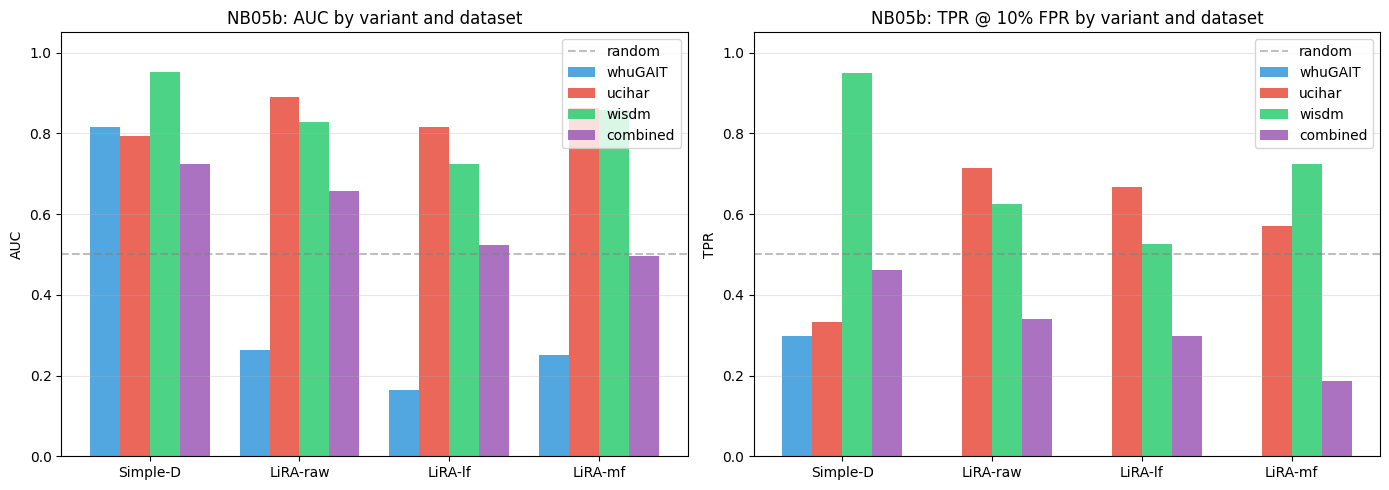

In [6]:
avail_ds = [ds for ds in DATASETS if ds in nb05b]
x        = np.arange(len(VARIANTS))
width    = 0.8 / max(len(avail_ds), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df_plot, title, ylabel) in zip(axes, [
    (df_auc, 'AUC', 'AUC'),
    (df_tpr, 'TPR @ 10% FPR', 'TPR'),
]):
    for i, ds in enumerate(avail_ds):
        vals = [df_plot.loc[ds, v] if v in df_plot.columns else np.nan for v in VARIANTS]
        offset = (i - len(avail_ds)/2 + 0.5) * width
        ax.bar(x + offset, vals, width, label=ds, color=COLORS[ds], alpha=0.85)
    ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='random')
    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(ylabel)
    ax.set_title(f'NB05b: {title} by variant and dataset')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb05b_lira.png', dpi=150)
plt.show()

## 3. NB05c — Shadow init threat model comparison (grey-box vs warm vs cold)

Three shadow initialisation strategies by attacker knowledge:
- **Grey-box** (`target-init`): shadows start from the exact target LSTM weights
- **Black-box warm** (`surrogate-init`): shadows start from an independently trained surrogate
- **Black-box cold** (`random-init`): shadows start from Xavier random init — attacker knows only the architecture

The threat model comparison uses raw-δ for all three strategies (Figure 1).
Cold-start consistently outperforms warm across datasets, because random initialisation gives each shadow an independent starting point and produces more diverse OUT distributions for the LiRA test.
Since warm adds no benefit over cold, the delta variant comparison (raw / logit-first / mean-first) is done on cold-start only (Figure 2).

In [7]:
from scipy.stats import norm as sp_norm
from sklearn.metrics import roc_curve

def tpr_at_fpr(scores, labels, target_fpr=0.10):
    fpr, tpr, _ = roc_curve(labels, scores)
    # largest TPR where FPR <= target_fpr
    valid = [(t, f) for f, t in zip(fpr, tpr) if f <= target_fpr]
    return round(max(t for t, _ in valid), 3) if valid else 0.0

def lira_metrics_from_shadow_json(shadow_path, target_deltas_path, threshold=0.5):
    """
    For each subject compute LiRA score = Φ(δ_target; μ_out, σ_out).
    Returns per-variant {'acc': float, 'auc': float, 'tpr10': float}.
    """
    with open(shadow_path) as f:
        shadow = json.load(f)
    td = np.load(target_deltas_path, allow_pickle=True)

    member_ids    = list(td['member_ids'])
    nonmember_ids = list(td['nonmember_ids'])
    all_ids = member_ids + nonmember_ids
    labels  = [1] * len(member_ids) + [0] * len(nonmember_ids)

    results = {}
    for v, td_key in [('raw', 'member_raw'), ('lf', 'member_lf'), ('mf', 'member_mf')]:
        td_v = {**dict(zip(member_ids,    td[td_key])),
                **dict(zip(nonmember_ids, td[f'nonmember_{v}']))}
        per_subj = shadow[v]
        scores, valid_labels = [], []
        for sid, lbl in zip(all_ids, labels):
            deltas = per_subj.get(str(sid), [])
            if len(deltas) < 5 or sid not in td_v:
                continue
            mu    = float(np.mean(deltas))
            sigma = float(np.std(deltas, ddof=1)) + 1e-6
            scores.append(float(sp_norm.cdf(td_v[sid], mu, sigma)))
            valid_labels.append(lbl)
        if len(set(valid_labels)) < 2:
            results[v] = {'acc': np.nan, 'auc': np.nan, 'tpr10': np.nan}
            continue
        preds   = [1 if s >= threshold else 0 for s in scores]
        acc     = sum(p == l for p, l in zip(preds, valid_labels)) / len(valid_labels)
        auc     = roc_auc_score(valid_labels, scores)
        t10     = tpr_at_fpr(scores, valid_labels, 0.10)
        results[v] = {'acc': round(acc, 3), 'auc': round(auc, 3), 'tpr10': t10}
    return results

# ── Grey-box (NB05b per_subject_report) ──────────────────────────────────────
nb05b_metrics = {}
for ds in DATASETS:
    path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    if not path.exists():
        print(f'  {ds}: 05b report missing / skipping')
        continue
    with open(path) as f:
        r = json.load(f)
    ps = r['per_subject']
    nb05b_metrics[ds] = {}
    for v in ('Simple-D', 'LiRA-raw', 'LiRA-lf', 'LiRA-mf'):
        valid = [s for s in ps if v in s and s[v].get('score') is not None]
        if len(valid) < 2 or len(set(s['true_label'] for s in valid)) < 2:
            nb05b_metrics[ds][v] = {'acc': float('nan'), 'auc': float('nan'), 'tpr10': float('nan')}
            continue
        lbls   = [1 if s['true_label'] == 'member' else 0 for s in valid]
        scrs   = [s[v]['score'] for s in valid]
        correct = sum(
            1 for s in valid
            if s[v]['pred'] == ('M' if s['true_label'] == 'member' else 'NM')
        )
        nb05b_metrics[ds][v] = {
            'acc':   round(correct / len(valid), 3),
            'auc':   round(roc_auc_score(lbls, scrs), 3),
            'tpr10': tpr_at_fpr(scrs, lbls, 0.10),
        }
    print(f'  {ds} grey: ' + '  '.join(
        f'{v}=auc{nb05b_metrics[ds][v]["auc"]:.3f}/tpr10={nb05b_metrics[ds][v]["tpr10"]:.3f}'
        for v in nb05b_metrics[ds]))

# ── Warm / cold (NB05c shadow JSONs) ─────────────────────────────────────────
nb05c_warm_metrics = {}
nb05c_cold_metrics = {}
for ds in DATASETS:
    td_path   = ARTIFACT_DIR / ds / '05a_target_deltas.npz'
    warm_path = ARTIFACT_DIR / ds / f'05c_lira_warm_shadows_{ds}.json'
    cold_path = ARTIFACT_DIR / ds / f'05c_lira_cold_shadows_{ds}.json'
    if not td_path.exists():
        continue
    if warm_path.exists():
        nb05c_warm_metrics[ds] = lira_metrics_from_shadow_json(warm_path, td_path)
        print(f'  {ds} warm: ' + '  '.join(
            f'{k}=auc{m["auc"]:.3f}/tpr10={m["tpr10"]:.3f}' for k, m in nb05c_warm_metrics[ds].items()))
    if cold_path.exists():
        nb05c_cold_metrics[ds] = lira_metrics_from_shadow_json(cold_path, td_path)
        print(f'  {ds} cold: ' + '  '.join(
            f'{k}=auc{m["auc"]:.3f}/tpr10={m["tpr10"]:.3f}' for k, m in nb05c_cold_metrics[ds].items()))


  whuGAIT grey: Simple-D=auc0.815/tpr10=0.298  LiRA-raw=auc0.262/tpr10=0.000  LiRA-lf=auc0.163/tpr10=0.000  LiRA-mf=auc0.251/tpr10=0.000
  ucihar grey: Simple-D=auc0.794/tpr10=0.333  LiRA-raw=auc0.889/tpr10=0.714  LiRA-lf=auc0.815/tpr10=0.667  LiRA-mf=auc0.862/tpr10=0.571
  wisdm grey: Simple-D=auc0.952/tpr10=0.950  LiRA-raw=auc0.827/tpr10=0.625  LiRA-lf=auc0.723/tpr10=0.525  LiRA-mf=auc0.857/tpr10=0.725
  combined grey: Simple-D=auc0.723/tpr10=0.462  LiRA-raw=auc0.656/tpr10=0.341  LiRA-lf=auc0.524/tpr10=0.297  LiRA-mf=auc0.497/tpr10=0.187
  whuGAIT warm: raw=auc0.346/tpr10=0.048  lf=auc0.183/tpr10=0.000  mf=auc0.289/tpr10=0.000
  whuGAIT cold: raw=auc0.709/tpr10=0.417  lf=auc0.686/tpr10=0.381  mf=auc0.743/tpr10=0.274
  ucihar warm: raw=auc0.661/tpr10=0.000  lf=auc0.481/tpr10=0.000  mf=auc0.661/tpr10=0.000
  ucihar cold: raw=auc0.968/tpr10=0.905  lf=auc0.921/tpr10=0.667  mf=auc0.926/tpr10=0.762
  wisdm warm: raw=auc0.659/tpr10=0.250  lf=auc0.705/tpr10=0.350  mf=auc0.816/tpr10=0.550
  w

### Attack variants explained

#### Official LiRA (Carlini et al., 2022)

The original LiRA operates at the **sample level**. For each training sample `x`:
1. Train K shadow models that include `x` (IN) and K that exclude it (OUT)
2. For each shadow, compute the model's confidence `p = f(x)` (softmax probability of the correct class)
3. Apply the logit transform: `logit(p) = log(p / (1-p))`
4. Fit a Gaussian on the K OUT logit confidences → `(μ_out, σ_out)`
5. Score = `Φ(logit(p_target); μ_out, σ_out)`. how extreme is the target model's confidence relative to the OUT distribution

A member's target confidence tends to be **higher** than the OUT baseline (the model overfits to training samples), so the score is close to 1. A non-member sits inside the OUT distribution, so the score is close to 0.5.

---

#### Our adaptation: why δ instead of raw confidence

Our model is a **pair-based authenticator**, not a classifier. It takes two windows `(x1, x2)` and outputs `P(different person)`. There is no single "correct class confidence" for a subject - membership is expressed across many pairs, not a single sample.

We define the **delta signal** δ as our membership proxy:

> δ(s) = mean P(diff | same-person pairs of s) − mean P(diff | diff-person pairs of s)

A high δ means the authenticator separates same-person from different-person pairs well for subject `s`. Members trained into the model tend to have higher δ than non-members, because the model has seen and fitted to their gait pattern.

We then plug δ into the LiRA framework in place of raw confidence: K shadow models produce OUT-of-bag δ values per subject, we fit a Gaussian, and score with Φ(δ_target; μ_out, σ_out).

---

#### Three δ variants

**Simple-D**: no shadow models. Uses δ_target directly as the attack score. Fast and interpretable, but sensitive to subject-level gait variability: a subject with naturally distinct gait gets a high score regardless of membership.

**LiRA-raw**: shadow framework applied to raw δ. Corrects for subject-level baseline by comparing δ_target to the shadow OUT distribution, but the raw difference may be poorly scaled when pair scores cluster near 0 or 1.

**LiRA-lf** (logit-first): applies the logit transform to **each individual pair score** before computing the mean difference:

> δ_lf(s) = mean logit(P(diff | same-pairs)) − mean logit(P(diff | diff-pairs))

This is the closest adaptation to the original LiRA: the logit is applied per pair before aggregation, stabilising scores at the extremes. A pair where P(diff)=0.99 contributes logit(0.99)≈4.6 rather than 0.99, giving it proportionally more weight.

**LiRA-mf** (mean-first): applies the logit to the **mean** pair score rather than to each pair individually:

> δ_mf(s) = logit(mean P(diff | same-pairs)) − logit(mean P(diff | diff-pairs))

Less sensitive to outlier pairs; more stable when the number of pairs per subject is small. Closer to treating each subject as a single "super-sample".

---

#### Three shadow init strategies (all use member-aware splits)

| Strategy | Init | Attacker knowledge |
|---|---|---|
| Grey-box | Target model weights | Exact model parameters |
| Warm (surrogate) | Self-trained surrogate | Architecture + public gait data only |
| Cold (random) | Xavier random init | Architecture only |

Cold-init shadows are the most independent from the target — their OUT distribution represents a clean "never-seen-this-subject" baseline, which makes the Gaussian fit more discriminating. This is why cold-init achieves higher attack accuracy despite the attacker knowing least.

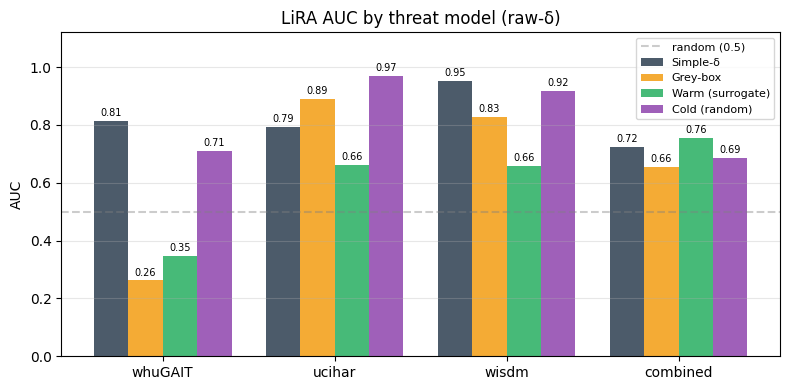

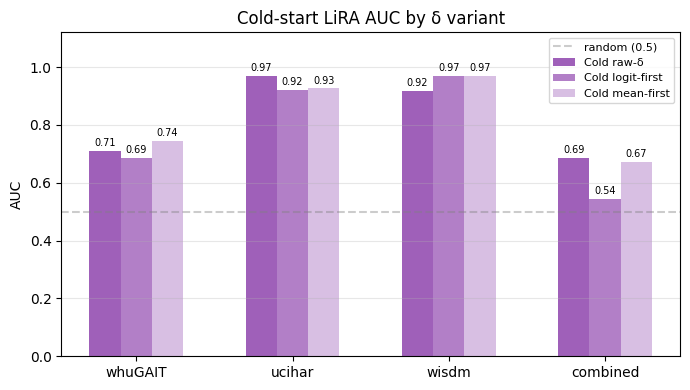


AUC summary:
          Simple-D  grey-raw  grey-lf  grey-mf  warm-raw  cold-raw  cold-lf  cold-mf
dataset                                                                             
whuGAIT      0.815     0.262    0.163    0.251     0.346     0.709    0.686    0.743
ucihar       0.794     0.889    0.815    0.862     0.661     0.968    0.921    0.926
wisdm        0.952     0.827    0.723    0.857     0.659     0.916    0.968    0.968
combined     0.723     0.656    0.524    0.497     0.755     0.686    0.544    0.673


In [8]:
def get_metric(ds, src, key, metric):
    if src == 'grey':
        v = nb05b_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    elif src == 'warm':
        v = nb05c_warm_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    else:
        v = nb05c_cold_metrics.get(ds, {}).get(key, {}).get(metric, np.nan)
    return float(v) if v is not None else np.nan

avail_ds = [ds for ds in DATASETS
            if ds in nb05b_metrics or ds in nb05c_warm_metrics or ds in nb05c_cold_metrics]
x  = np.arange(len(avail_ds))
w  = 0.20

# ── Figure 1: threat model comparison (raw-δ only) ───────────────────────────
THREAT_BARS = [
    ('Simple-D', 'grey', 'Simple-D',  '#2c3e50', 'Simple-δ'),
    ('grey-raw', 'grey', 'LiRA-raw',  '#f39c12', 'Grey-box'),
    ('warm-raw', 'warm', 'raw',        '#27ae60', 'Warm (surrogate)'),
    ('cold-raw', 'cold', 'raw',        '#8e44ad', 'Cold (random)'),
]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (_, src, key, color, label) in enumerate(THREAT_BARS):
    vals = [get_metric(ds, src, key, 'auc') for ds in avail_ds]
    offset = (i - len(THREAT_BARS) / 2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax.axhline(0.5, ls='--', color='grey', alpha=0.4, label='random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(avail_ds)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC')
ax.set_title('LiRA AUC by threat model (raw-δ)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb05c_threat_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: cold-start delta variant comparison ─────────────────────────────
DELTA_BARS = [
    ('cold-raw', 'cold', 'raw', '#8e44ad', 'Cold raw-δ'),
    ('cold-lf',  'cold', 'lf',  '#a569bd', 'Cold logit-first'),
    ('cold-mf',  'cold', 'mf',  '#d2b4de', 'Cold mean-first'),
]

fig, ax = plt.subplots(figsize=(7, 4))
for i, (_, src, key, color, label) in enumerate(DELTA_BARS):
    vals = [get_metric(ds, src, key, 'auc') for ds in avail_ds]
    offset = (i - len(DELTA_BARS) / 2 + 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax.axhline(0.5, ls='--', color='grey', alpha=0.4, label='random (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(avail_ds)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC')
ax.set_title('Cold-start LiRA AUC by δ variant')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_nb05c_cold_variants.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
ALL_COLS = [
    ('Simple-D',  'grey', 'Simple-D'),
    ('grey-raw',  'grey', 'LiRA-raw'),
    ('grey-lf',   'grey', 'LiRA-lf'),
    ('grey-mf',   'grey', 'LiRA-mf'),
    ('warm-raw',  'warm', 'raw'),
    ('cold-raw',  'cold', 'raw'),
    ('cold-lf',   'cold', 'lf'),
    ('cold-mf',   'cold', 'mf'),
]
rows = []
for ds in DATASETS:
    row = {'dataset': ds}
    for col, src, key in ALL_COLS:
        row[col] = get_metric(ds, src, key, 'auc')
    rows.append(row)
df_all = pd.DataFrame(rows).set_index('dataset').dropna(how='all')
print('\nAUC summary:')
print(df_all.round(3).to_string())

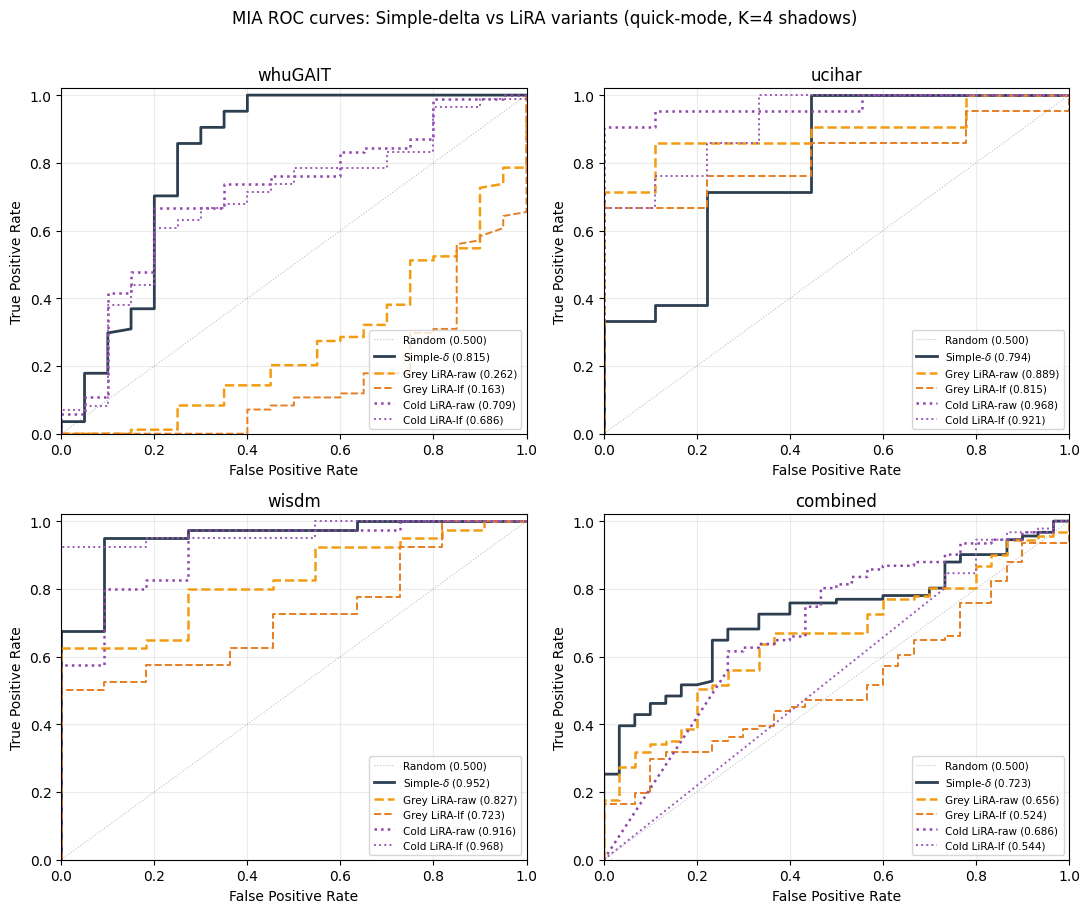

Saved mia_roc_comparison.png


In [9]:
from sklearn.metrics import roc_curve, auc as sk_auc

def get_roc_scores_from_report(report_path, variant='Simple-D'):
    with open(report_path) as f:
        r = json.load(f)
    valid = [s for s in r['per_subject']
             if variant in s and s[variant].get('score') is not None]
    scores = np.array([s[variant]['score'] for s in valid])
    labels = np.array([1 if s['true_label'] == 'member' else 0 for s in valid])
    return scores, labels

def get_roc_scores_from_shadow(shadow_path, td_path, variant='raw'):
    with open(shadow_path) as f:
        shadow = json.load(f)
    td = np.load(td_path, allow_pickle=True)
    member_ids    = list(td['member_ids'])
    nonmember_ids = list(td['nonmember_ids'])
    all_ids = member_ids + nonmember_ids
    labels_all = [1] * len(member_ids) + [0] * len(nonmember_ids)
    td_key = {'raw': 'member_raw', 'lf': 'member_lf', 'mf': 'member_mf'}[variant]
    td_v = {**dict(zip(member_ids,    td[td_key])),
            **dict(zip(nonmember_ids, td[f'nonmember_{variant}']))}
    per_subj = shadow[variant]
    scores, labels = [], []
    for sid, lbl in zip(all_ids, labels_all):
        deltas = per_subj.get(str(sid), [])
        if len(deltas) < 5 or sid not in td_v:
            continue
        mu    = float(np.mean(deltas))
        sigma = float(np.std(deltas, ddof=1)) + 1e-6
        scores.append(float(sp_norm.cdf(td_v[sid], mu, sigma)))
        labels.append(lbl)
    return np.array(scores), np.array(labels)

ATTACK_STYLES = [
    ('Simple-D',    'Simple-$\\delta$',  '#2c3e50', 2.0, '-'),
    ('grey-raw',    'Grey LiRA-raw',      '#f39c12', 1.8, '--'),
    ('grey-lf',     'Grey LiRA-lf',       '#e67e22', 1.4, '--'),
    ('cold-raw',    'Cold LiRA-raw',      '#8e44ad', 1.8, ':'),
    ('cold-lf',     'Cold LiRA-lf',       '#9b59b6', 1.4, ':'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, ds in enumerate(DATASETS):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], color='grey', lw=0.8, ls=':', alpha=0.5, label='Random (0.500)')

    report_path = ARTIFACT_DIR / ds / '05b_per_subject_report.json'
    td_path     = ARTIFACT_DIR / ds / '05a_target_deltas.npz'
    cold_path   = ARTIFACT_DIR / ds / f'05c_lira_cold_shadows_{ds}.json'

    if not report_path.exists():
        ax.set_title(f'{ds} — no data')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        continue

    for key, label, color, lw, ls in ATTACK_STYLES:
        if key == 'Simple-D':
            scores, labels = get_roc_scores_from_report(report_path, 'Simple-D')
        elif key.startswith('grey-'):
            v = 'LiRA-' + key.split('-')[1]
            scores, labels = get_roc_scores_from_report(report_path, v)
        elif key.startswith('cold-') and td_path.exists() and cold_path.exists():
            v = key.split('-')[1]
            scores, labels = get_roc_scores_from_shadow(cold_path, td_path, v)
        else:
            continue

        if len(set(labels)) < 2 or len(scores) == 0:
            continue
        fpr, tpr, _ = roc_curve(labels, scores)
        a = sk_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{label} ({a:.3f})')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(ds)
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle('MIA ROC curves: Simple-delta vs LiRA variants (quick-mode, K=4 shadows)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'mia_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved mia_roc_comparison.png')


In [10]:
from src.utils.latex_writer import write_latex_metrics

def _f(v, fmt='.3f'):
    return f'{v:{fmt}}' if isinstance(v, (int, float)) and not np.isnan(float(v)) else '—'

for ds in DATASETS:
    if ds not in nb05b_metrics and ds not in nb05c_cold_metrics:
        continue
    metrics = {}
    # Simple delta (NB04)
    if ds in nb04:
        metrics['simplDAUC']      = _f(nb04[ds]['mia_auc'])
        metrics['simplDDeltaGap'] = _f(nb04[ds]['delta_gap'])
    # Simple delta TPR@10%FPR (from nb05b Simple-D variant)
    # Note: key uses 'ten' not '10' — LaTeX command names cannot contain digits
    if ds in nb05b and 'Simple-D' in nb05b[ds]:
        metrics['simplDTPRten'] = _f(nb05b[ds]['Simple-D'].get('tpr10', float('nan')))
    # Grey-box AUC + TPR@10%FPR (raw variant used in threat-model table)
    for v in ['raw', 'lf', 'mf']:
        m = nb05b_metrics.get(ds, {}).get(f'LiRA-{v}', {})
        metrics[f'greyLira{v.capitalize()}AUC']    = _f(m.get('auc',   np.nan))
        metrics[f'greyLira{v.capitalize()}ACC']    = _f(m.get('acc',   np.nan))
        metrics[f'greyLira{v.capitalize()}TPRten'] = _f(m.get('tpr10', np.nan))
    # Warm-start AUC + TPR@10%FPR (raw only)
    m = nb05c_warm_metrics.get(ds, {}).get('raw', {})
    metrics['warmLiraRawAUC']    = _f(m.get('auc',   np.nan))
    metrics['warmLiraRawACC']    = _f(m.get('acc',   np.nan))
    metrics['warmLiraRawTPRten'] = _f(m.get('tpr10', np.nan))
    # Cold-start AUC + TPR@10%FPR (all three delta variants)
    for v in ['raw', 'lf', 'mf']:
        m = nb05c_cold_metrics.get(ds, {}).get(v, {})
        metrics[f'coldLira{v.capitalize()}AUC']    = _f(m.get('auc',   np.nan))
        metrics[f'coldLira{v.capitalize()}ACC']    = _f(m.get('acc',   np.nan))
        metrics[f'coldLira{v.capitalize()}TPRten'] = _f(m.get('tpr10', np.nan))

    prefix = ds.replace('-', '')
    write_latex_metrics(f'compare_mia_{ds}', metrics,
                        output_dir=str(TEX_DIR), key_prefix=prefix)

print(f'LaTeX written to {TEX_DIR}/ (compare_mia_{{ds}}_metrics.tex)')


LaTeX metrics written: ../../latex/generated/compare_mia_whuGAIT_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_mia_ucihar_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_mia_wisdm_metrics.tex
LaTeX metrics written: ../../latex/generated/compare_mia_combined_metrics.tex
LaTeX written to ../../latex/generated/ (compare_mia_{ds}_metrics.tex)
